In [1]:
# Please uncomment this out when you are running this lab on google colab!
import os

# Set KaggleHub cache to a directory inside /content/
os.environ["KAGGLEHUB_CACHE"] = "/content/data"

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sayedgamal99/smoke-fire-detection-yolo")

print("Path to dataset files:", path)

100%|██████████| 2.84G/2.84G [02:15<00:00, 22.4MB/s]

Extracting files...


Path to dataset files: /content/data/datasets/sayedgamal99/smoke-fire-detection-yolo/versions/1


In [8]:
# Load dataset configuration
dataset_path = "/content/data/datasets/sayedgamal99/smoke-fire-detection-yolo/versions/1/data.yaml"

# Check dataset information
print(open(dataset_path).read())

path: /kaggle/working/D Fire Dataset  # dataset root dir
train: data/train/images  # train images (relative to 'path')
val: data/val/images  # val images (relative to 'path')
test: data/test/images  # test images (relative to 'path')

# Classes
names: ['smoke', 'fire']  # Replace with your actual class names

# Counts
nc: 2  # number of classes
train_count: 14122
val_count: 3099
test_count: 4306



In [4]:
# Install Ultralytics library which has Yolo
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 12.7 MB/s eta 0:00:00


In [5]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
# Load YOLOv8 model (small version)
model = YOLO("yolov8s.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.



image 1/1 /content/data/datasets/sayedgamal99/smoke-fire-detection-yolo/versions/1/data/test/images/AoF06726.jpg: 384x640 (no detections), 44.6ms
Speed: 11.3ms preprocess, 44.6ms inference, 3.8ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict


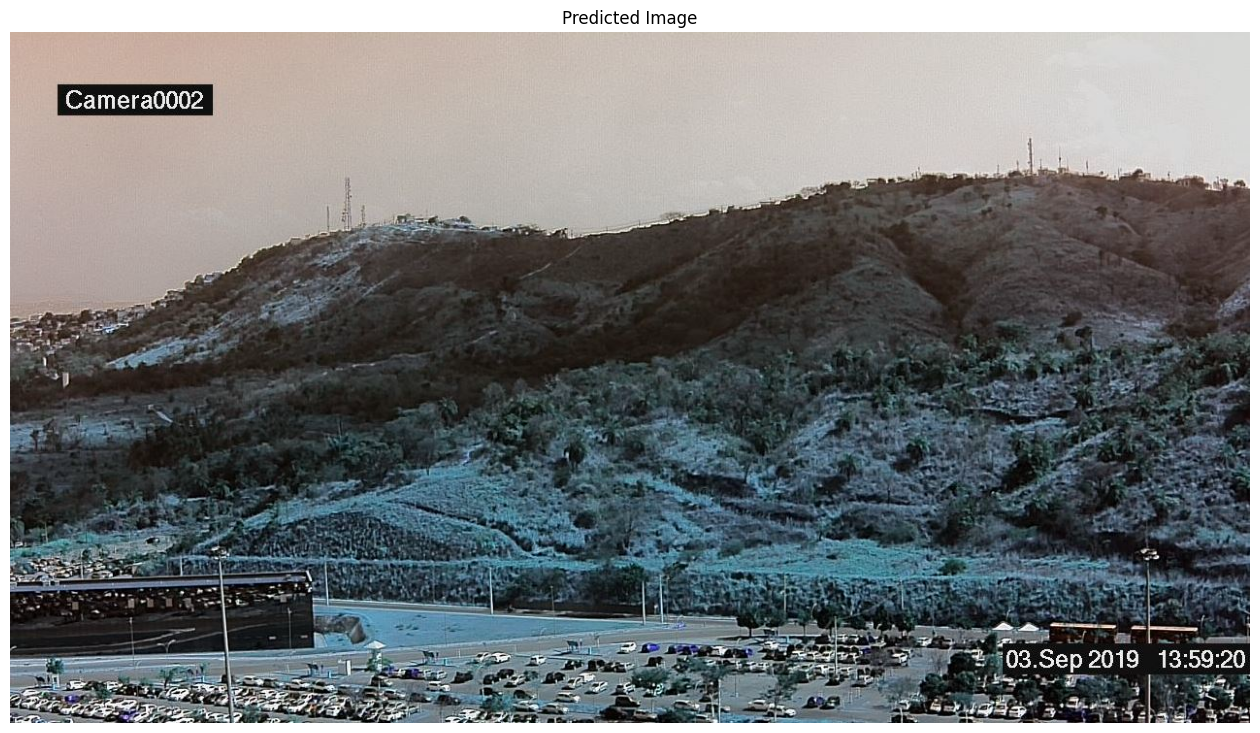

In [6]:
# Load an image and run inference
results = model("/content/data/datasets/sayedgamal99/smoke-fire-detection-yolo/versions/1/data/test/images/AoF06726.jpg", save=True)

# Convert result to a NumPy array and display
predicted_image = results[0].plot()  # Convert prediction to an image

plt.figure(figsize=(16, 16))
plt.imshow(predicted_image)
plt.axis("off")
plt.title("Predicted Image")
plt.show()

In [10]:
# Read and fix the data.yaml file
import yaml

yaml_path = '/content/data/datasets/sayedgamal99/smoke-fire-detection-yolo/versions/1/data.yaml'

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

# Update paths to correct locations
data['path'] = '/content/data/datasets/sayedgamal99/smoke-fire-detection-yolo/versions/1'
data['train'] = 'data/train/images'  # relative to path above
data['val'] = 'data/val/images'      # relative to path above

# Save the corrected yaml
with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

In [11]:
# Train on the wind turbine dataset
model.train(data=dataset_path, epochs=20, imgsz=640)


Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/datasets/sayedgamal99/smoke-fire-detection-yolo/versions/1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimize

KeyboardInterrupt: 